In [1]:
import scanpy as sc

In [66]:
adata_xenium_ov = sc.read_h5ad('/nfs/team361/sb75/DATASETS/silver/spatch/dataset_id_1.h5ad')
adata_cosmx_ov = sc.read_h5ad('/nfs/team361/sb75/DATASETS/silver/spatch/dataset_id_4.h5ad')

In [67]:
print(adata_xenium_ov)

AnnData object with n_obs × n_vars = 410193 × 5001
    obs: 'codex_common', 'annotation', 'spatial_cluster', 'high_quality'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'CODEX resolution', 'DAPI resolution', 'H&E resolution', 'batch', 'patient_metadata'
    obsm: 'spatial'


In [68]:
adata_xenium_ov_sub.obs

,codex_common,annotation,spatial_cluster,high_quality
aaaadpgk-1,1,CD8T,1,1
aaaafcja-1,1,CD8T,1,1
aaaahekl-1,1,CD8T,1,1
aaaajack-1,1,CD8T,1,1
aaaalnbf-1,1,Plasma,1,1
...,...,...,...,...
oijkboei-1,1,NaN,NaN,0
oijkceha-1,1,NaN,NaN,0
oijkjgjb-1,1,NaN,NaN,0
oijkkaed-1,1,Macrophage,0,1


In [69]:
print(adata_cosmx_ov)

AnnData object with n_obs × n_vars = 289272 × 6175
    obs: 'codex_common', 'annotation', 'spatial_cluster', 'high_quality'
    uns: 'CODEX resolution', 'DAPI resolution', 'H&E resolution', 'batch', 'patient_metadata'
    obsm: 'spatial'


In [70]:
adata_cosmx_ov.obs

,codex_common,annotation,spatial_cluster,high_quality
1_1,1,NaN,NaN,0
2_1,1,NaN,NaN,0
3_1,1,NaN,NaN,0
4_1,1,NaN,NaN,0
5_1,1,NaN,NaN,0
...,...,...,...,...
903_236,1,Epithelial,1,1
904_236,1,Fibroblast,0,1
905_236,1,Epithelial,1,1
906_236,1,Epithelial,0,1


In [71]:
# Ensure gene names are unique first
adata_xenium_ov.var_names_make_unique()
adata_cosmx_ov.var_names_make_unique()

# Get shared genes and sort alphabetically
shared_genes = adata_xenium_ov.var_names.intersection(
    adata_cosmx_ov.var_names
).sort_values()

# Subset both AnnData objects to the same sorted gene order
adata_xenium_ov = adata_xenium_ov[:, shared_genes].copy()
adata_cosmx_ov = adata_cosmx_ov[:, shared_genes].copy()

# Confirm same genes in same order
assert adata_xenium_ov.var_names.equals(adata_cosmx_ov.var_names)

# Add Xenium var columns to CosMx var
for col in adata_xenium_ov.var.columns:
    adata_cosmx_ov.var[col] = adata_xenium_ov.var[col].values

In [72]:
adata_xenium_ov.var

,gene_ids,feature_types,genome
AAMP,ENSG00000127837,Gene Expression,Unknown
ABAT,ENSG00000183044,Gene Expression,Unknown
ABCA1,ENSG00000165029,Gene Expression,Unknown
ABCB1,ENSG00000085563,Gene Expression,Unknown
ABCC1,ENSG00000103222,Gene Expression,Unknown
...,...,...,...
ZNF296,ENSG00000170684,Gene Expression,Unknown
ZNF804A,ENSG00000170396,Gene Expression,Unknown
ZSWIM6,ENSG00000130449,Gene Expression,Unknown
ZYG11B,ENSG00000162378,Gene Expression,Unknown


In [73]:
adata_cosmx_ov.var

,gene_ids,feature_types,genome
AAMP,ENSG00000127837,Gene Expression,Unknown
ABAT,ENSG00000183044,Gene Expression,Unknown
ABCA1,ENSG00000165029,Gene Expression,Unknown
ABCB1,ENSG00000085563,Gene Expression,Unknown
ABCC1,ENSG00000103222,Gene Expression,Unknown
...,...,...,...
ZNF296,ENSG00000170684,Gene Expression,Unknown
ZNF804A,ENSG00000170396,Gene Expression,Unknown
ZSWIM6,ENSG00000130449,Gene Expression,Unknown
ZYG11B,ENSG00000162378,Gene Expression,Unknown


In [76]:
adata_tmp = sc.read_h5ad('/nfs/team361/sb75/DATASETS/silver/spatch_1p/dataset_id_2.h5ad')

In [77]:
adata_tmp.obs

,codex_common,annotation,spatial_cluster,high_quality,cell_id
aaaabkfh-1,1,Hepatocyte,3,1,spatch_batch2_aaaabkfh-1
aaaapcjn-1,1,Hepatocyte,3,1,spatch_batch2_aaaapcjn-1
aaablecg-1,1,Hepatocyte,3,1,spatch_batch2_aaablecg-1
aaablhmb-1,1,Hepatocyte,3,1,spatch_batch2_aaablhmb-1
aaabmfjk-1,1,Hepatocyte,3,1,spatch_batch2_aaabmfjk-1
...,...,...,...,...,...
oijlonjc-1,1,NaN,NaN,0,spatch_batch2_oijlonjc-1
oijmcejp-1,1,NaN,NaN,0,spatch_batch2_oijmcejp-1
oijmdlho-1,1,NaN,NaN,0,spatch_batch2_oijmdlho-1
oijmfggc-1,1,NaN,NaN,0,spatch_batch2_oijmfggc-1


In [83]:
adata_xenium_ov.obs['cell_id'] = 'spatch_' + adata_xenium_ov.uns['batch'] + '_' + adata_xenium_ov.obs.index
adata_cosmx_ov.obs['cell_id'] = 'spatch_' + adata_cosmx_ov.uns['batch'] + '_' + adata_cosmx_ov.obs.index

In [84]:
adata_xenium_ov.write('/nfs/team361/sb75/DATASETS/silver/spatch_ov_1p/dataset_id_1.h5ad')
adata_cosmx_ov.write('/nfs/team361/sb75/DATASETS/silver/spatch_ov_1p/dataset_id_4.h5ad')

/tmp/ipykernel_1326403/1188110370.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_xenium_ov_sub, spot_size=20)


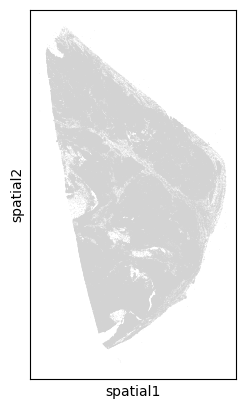

In [10]:
sc.pl.spatial(adata_xenium_ov_sub, spot_size=20)

In [13]:
adata_cosmx_ov_sub.obs

,codex_common,annotation,spatial_cluster,high_quality
1_1,1,NaN,NaN,0
2_1,1,NaN,NaN,0
3_1,1,NaN,NaN,0
4_1,1,NaN,NaN,0
5_1,1,NaN,NaN,0
...,...,...,...,...
903_236,1,Epithelial,1,1
904_236,1,Fibroblast,0,1
905_236,1,Epithelial,1,1
906_236,1,Epithelial,0,1


In [25]:
adata_cosmx_ov_sub.obs['high_quality'].value_counts()

high_quality
1    260447
0     28825
Name: count, dtype: int64

/tmp/ipykernel_1326403/38684593.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_cosmx_ov_sub, spot_size=20)


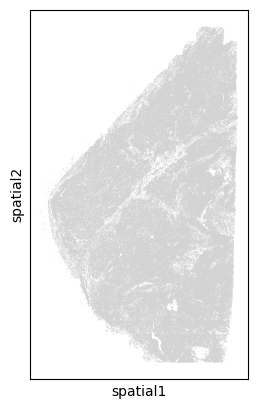

In [11]:
sc.pl.spatial(adata_cosmx_ov_sub, spot_size=20)

In [85]:
adata_xenium_hcc = sc.read_h5ad('/nfs/team361/sb75/DATASETS/silver/spatch/dataset_id_2.h5ad')
adata_cosmx_hcc = sc.read_h5ad('/nfs/team361/sb75/DATASETS/silver/spatch/dataset_id_5.h5ad')

In [86]:
# Ensure gene names are unique first
adata_xenium_hcc.var_names_make_unique()
adata_cosmx_hcc.var_names_make_unique()

# Get shared genes and sort alphabetically
shared_genes = adata_xenium_hcc.var_names.intersection(
    adata_cosmx_hcc.var_names
).sort_values()

# Subset both AnnData objects to the same sorted gene order
adata_xenium_hcc = adata_xenium_hcc[:, shared_genes].copy()
adata_cosmx_hcc = adata_cosmx_hcc[:, shared_genes].copy()

# Confirm same genes in same order
assert adata_xenium_hcc.var_names.equals(adata_cosmx_hcc.var_names)

# Add Xenium var columns to CosMx var
for col in adata_xenium_hcc.var.columns:
    adata_cosmx_hcc.var[col] = adata_xenium_hcc.var[col].values

In [87]:
adata_xenium_hcc.obs['cell_id'] = 'spatch_' + adata_xenium_hcc.uns['batch'] + '_' + adata_xenium_hcc.obs.index
adata_cosmx_hcc.obs['cell_id'] = 'spatch_' + adata_cosmx_hcc.uns['batch'] + '_' + adata_cosmx_hcc.obs.index

In [88]:
adata_xenium_hcc.write('/nfs/team361/sb75/DATASETS/silver/spatch_hcc_1p/dataset_id_2.h5ad')
adata_cosmx_hcc.write('/nfs/team361/sb75/DATASETS/silver/spatch_hcc_1p/dataset_id_5.h5ad')

/tmp/ipykernel_1326403/2485567354.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_xenium_hcc_sub, spot_size=20)


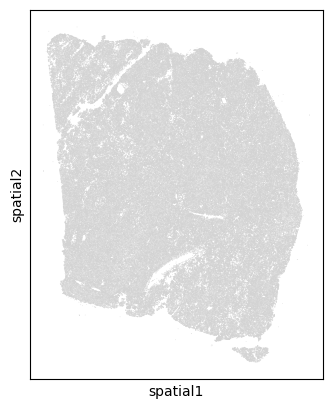

In [18]:
sc.pl.spatial(adata_xenium_hcc_sub, spot_size=20)

/tmp/ipykernel_1326403/2714476953.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_cosmx_hcc_sub, spot_size=20)


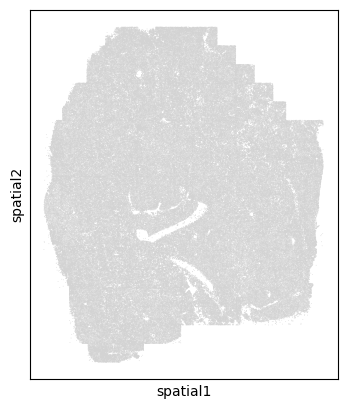

In [17]:
sc.pl.spatial(adata_cosmx_hcc_sub, spot_size=20)

In [91]:
adata_xenium_coad = sc.read_h5ad('/nfs/team361/sb75/DATASETS/silver/spatch/dataset_id_3.h5ad')
adata_cosmx_coad = sc.read_h5ad('/nfs/team361/sb75/DATASETS/silver/spatch/dataset_id_6.h5ad')

In [92]:
# Ensure gene names are unique first
adata_xenium_coad.var_names_make_unique()
adata_cosmx_coad.var_names_make_unique()

# Get shared genes and sort alphabetically
shared_genes = adata_xenium_coad.var_names.intersection(
    adata_cosmx_coad.var_names
).sort_values()

# Subset both AnnData objects to the same sorted gene order
adata_xenium_coad = adata_xenium_coad[:, shared_genes].copy()
adata_cosmx_coad = adata_cosmx_coad[:, shared_genes].copy()

# Confirm same genes in same order
assert adata_xenium_coad.var_names.equals(adata_cosmx_coad.var_names)

# Add Xenium var columns to CosMx var
for col in adata_xenium_coad.var.columns:
    adata_cosmx_coad.var[col] = adata_xenium_coad.var[col].values

In [93]:
adata_xenium_coad.obs['cell_id'] = 'spatch_' + adata_xenium_coad.uns['batch'] + '_' + adata_xenium_coad.obs.index
adata_cosmx_coad.obs['cell_id'] = 'spatch_' + adata_cosmx_coad.uns['batch'] + '_' + adata_cosmx_coad.obs.index

In [94]:
adata_xenium_coad.write('/nfs/team361/sb75/DATASETS/silver/spatch_coad_1p/dataset_id_3.h5ad')
adata_cosmx_coad.write('/nfs/team361/sb75/DATASETS/silver/spatch_coad_1p/dataset_id_6.h5ad')

/tmp/ipykernel_1326403/1370065760.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_xenium_coad_sub, spot_size=20)


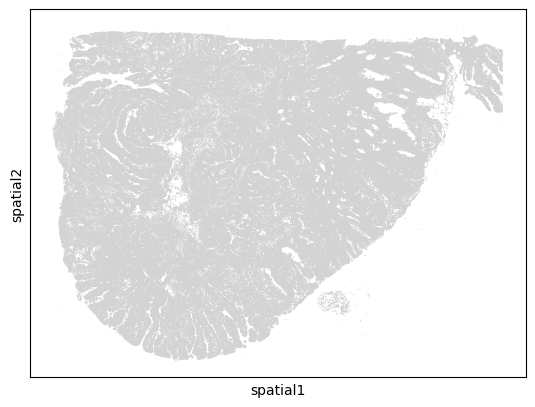

In [23]:
sc.pl.spatial(adata_xenium_coad_sub, spot_size=20)

/tmp/ipykernel_1326403/3573479284.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_cosmx_coad_sub, spot_size=20)


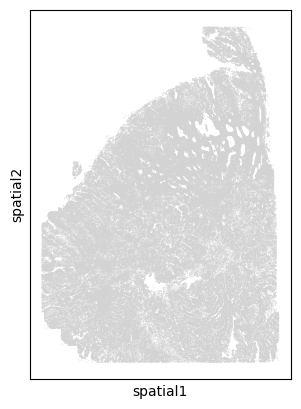

In [24]:
sc.pl.spatial(adata_cosmx_coad_sub, spot_size=20)